# 📊 Week 7: Statistical Business Analysis
## Introduction to Statistics for Data Science

**Datasets Used:**
- `business_data.csv` — Sales data (100 rows, 7 columns)
- `customer_churn.csv` — Customer churn data (500 rows, 9 columns)

**Analysis Plan:**
1. Descriptive Statistics
2. Data Distribution Analysis
3. Correlation Analysis
4. Hypothesis Testing (3+ tests)
5. Confidence Intervals
6. Regression Analysis
7. Business Insights & Recommendations


## ⚙️ Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import (ttest_ind, ttest_1samp, f_oneway,
                         pearsonr, normaltest, shapiro)
import statsmodels.api as sm
from statsmodels.stats.power import TTestIndPower
import warnings
warnings.filterwarnings('ignore')

# Style
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("husl")

print("✅ All libraries loaded successfully")
print(f"NumPy: {np.__version__} | Pandas: {pd.__version__}")


✅ All libraries loaded successfully
NumPy: 2.4.4 | Pandas: 3.0.2


---
## 📅 Day 1: Descriptive Statistics
Calculate mean, median, mode, standard deviation for key business metrics.


In [2]:
# Load datasets
sales = pd.read_csv('business_data.csv')
churn = pd.read_csv('customer_churn.csv')

print("=" * 60)
print("SALES DATASET — Shape:", sales.shape)
print("=" * 60)
print(sales.head())
print("\nData Types:")
print(sales.dtypes)


SALES DATASET — Shape: (100, 7)
         Date     Product  Quantity  Price Customer_ID Region  Total_Sales
0  2024-01-01       Phone         7  37300     CUST001   East       261100
1  2024-01-02  Headphones         4  15406     CUST002  North        61624
2  2024-01-03       Phone         2  21746     CUST003   West        43492
3  2024-01-04  Headphones         1  30895     CUST004   East        30895
4  2024-01-05      Laptop         8  39835     CUST005  North       318680

Data Types:
Date             str
Product          str
Quantity       int64
Price          int64
Customer_ID      str
Region           str
Total_Sales    int64
dtype: object


In [3]:
# ── DESCRIPTIVE STATISTICS: SALES ──────────────────────────
numeric_cols = ['Quantity', 'Price', 'Total_Sales']

print("=" * 65)
print(" COMPREHENSIVE DESCRIPTIVE STATISTICS — SALES DATA")
print("=" * 65)

for col in numeric_cols:
    data = sales[col]
    mode_val = data.mode()[0]
    cv = (data.std() / data.mean()) * 100      # Coefficient of Variation
    skew = data.skew()
    kurt = data.kurtosis()
    iqr  = data.quantile(0.75) - data.quantile(0.25)

    print(f"\n📌 {col.upper()}")
    print(f"   Mean        : {data.mean():>12,.2f}")
    print(f"   Median      : {data.median():>12,.2f}")
    print(f"   Mode        : {mode_val:>12,.2f}")
    print(f"   Std Dev     : {data.std():>12,.2f}")
    print(f"   Variance    : {data.var():>12,.2f}")
    print(f"   Min / Max   : {data.min():>12,.2f} / {data.max():,.2f}")
    print(f"   Q1 / Q3     : {data.quantile(0.25):>12,.2f} / {data.quantile(0.75):,.2f}")
    print(f"   IQR         : {iqr:>12,.2f}")
    print(f"   CV (%)      : {cv:>12.2f}%")
    print(f"   Skewness    : {skew:>12.4f}  {'(right-skewed)' if skew > 0 else '(left-skewed)'}")
    print(f"   Kurtosis    : {kurt:>12.4f}")


 COMPREHENSIVE DESCRIPTIVE STATISTICS — SALES DATA

📌 QUANTITY
   Mean        :         4.78
   Median      :         5.00
   Mode        :         4.00
   Std Dev     :         2.59
   Variance    :         6.70
   Min / Max   :         1.00 / 9.00
   Q1 / Q3     :         2.75 / 7.00
   IQR         :         4.25
   CV (%)      :        54.15%
   Skewness    :       0.0730  (right-skewed)
   Kurtosis    :      -1.2000

📌 PRICE
   Mean        :    25,808.51
   Median      :    24,192.00
   Mode        :     1,308.00
   Std Dev     :    13,917.63
   Variance    : 193,700,431.55
   Min / Max   :     1,308.00 / 49,930.00
   Q1 / Q3     :    14,965.25 / 38,682.25
   IQR         :    23,717.00
   CV (%)      :        53.93%
   Skewness    :      -0.0058  (left-skewed)
   Kurtosis    :      -1.2591

📌 TOTAL_SALES
   Mean        :   123,650.48
   Median      :    97,955.50
   Mode        :     6,540.00
   Std Dev     :   100,161.09
   Variance    : 10,032,243,003.46
   Min / Max   :     6,54

In [4]:
# ── DESCRIPTIVE STATISTICS: CHURN ──────────────────────────
churn_num = ['Tenure', 'MonthlyCharges', 'TotalCharges']

print("=" * 65)
print(" COMPREHENSIVE DESCRIPTIVE STATISTICS — CHURN DATA")
print("=" * 65)

for col in churn_num:
    data = churn[col]
    mode_val = data.mode()[0]
    cv = (data.std() / data.mean()) * 100
    print(f"\n📌 {col.upper()}")
    print(f"   Mean        : {data.mean():>12,.2f}")
    print(f"   Median      : {data.median():>12,.2f}")
    print(f"   Mode        : {mode_val:>12,.2f}")
    print(f"   Std Dev     : {data.std():>12,.2f}")
    print(f"   Min / Max   : {data.min():>12,.2f} / {data.max():,.2f}")
    print(f"   IQR         : {(data.quantile(0.75)-data.quantile(0.25)):>12,.2f}")
    print(f"   CV (%)      : {cv:>12.2f}%")
    print(f"   Skewness    : {data.skew():>12.4f}")

print("\n\nChurn Rate:", f"{churn['Churn'].mean()*100:.1f}%")
print("Senior Citizens:", f"{churn['SeniorCitizen'].mean()*100:.1f}%")


 COMPREHENSIVE DESCRIPTIVE STATISTICS — CHURN DATA

📌 TENURE
   Mean        :        36.53
   Median      :        37.00
   Mode        :         3.00
   Std Dev     :        20.67
   Min / Max   :         1.00 / 71.00
   IQR         :        35.00
   CV (%)      :        56.57%
   Skewness    :      -0.0907

📌 MONTHLYCHARGES
   Mean        :       113.64
   Median      :       115.00
   Mode        :       115.00
   Std Dev     :        51.80
   Min / Max   :        20.00 / 199.00
   IQR         :        91.00
   CV (%)      :        45.58%
   Skewness    :      -0.0886

📌 TOTALCHARGES
   Mean        :     4,237.88
   Median      :     4,182.50
   Mode        :     4,023.00
   Std Dev     :     2,260.62
   Min / Max   :       159.00 / 7,992.00
   IQR         :     4,029.50
   CV (%)      :        53.34%
   Skewness    :      -0.0266


Churn Rate: 10.6%
Senior Citizens: 49.8%


---
## 📅 Day 2: Data Distribution Analysis
Create histograms and density plots; test for normality.


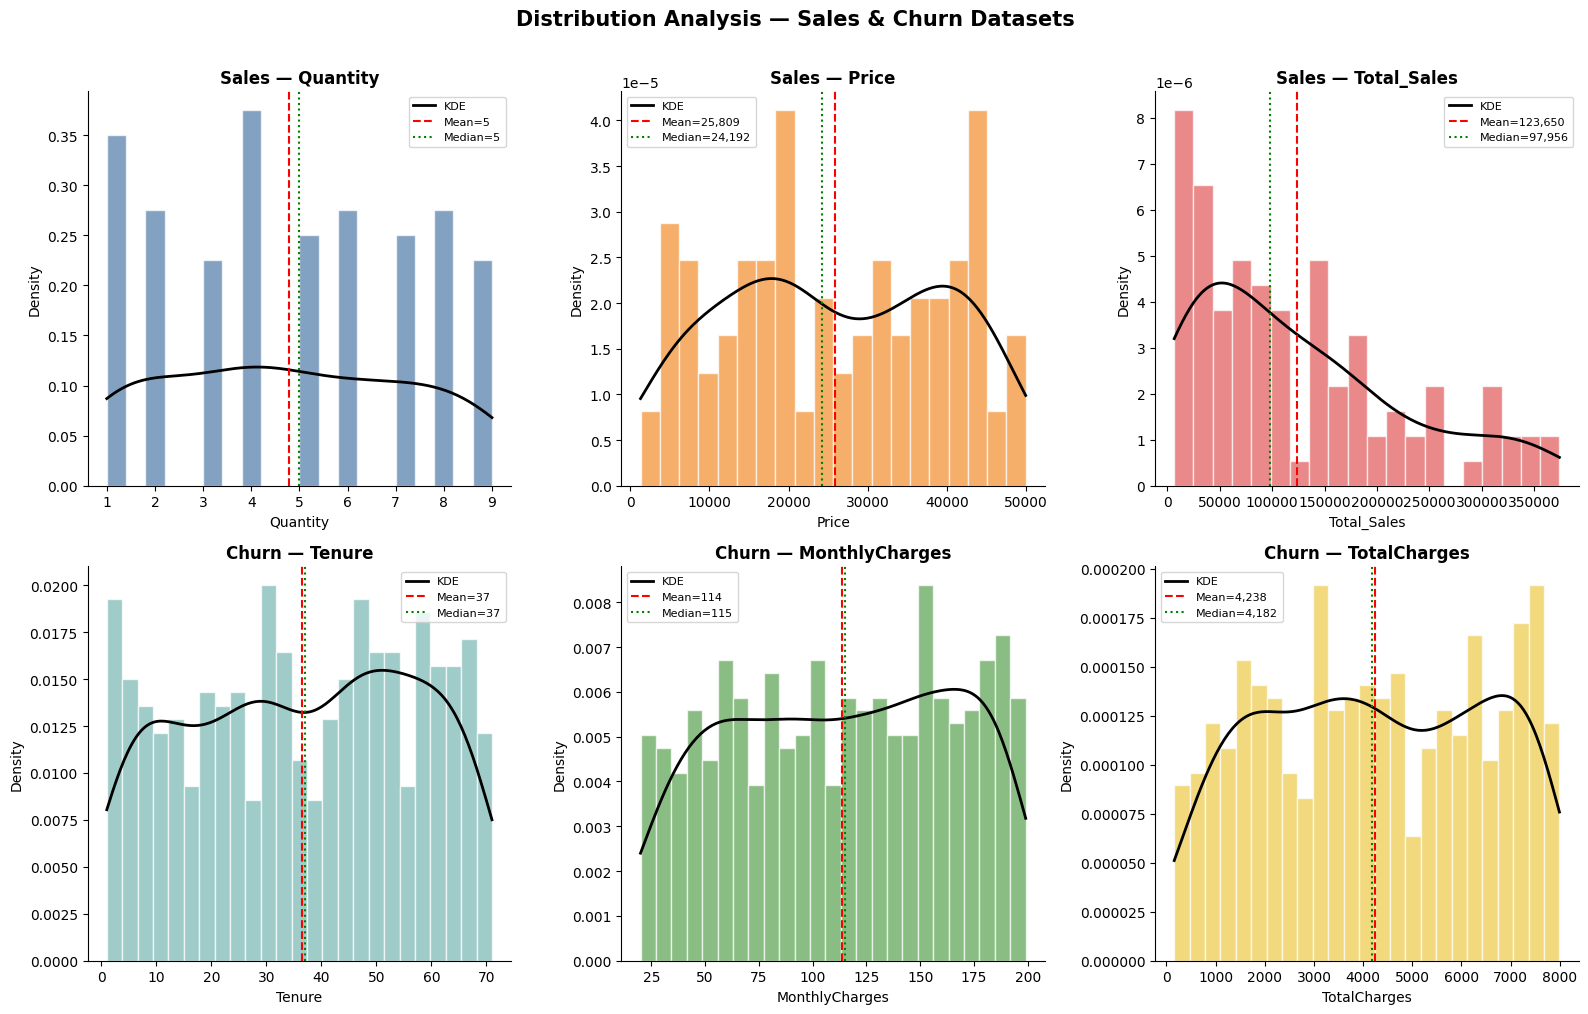

✅ Distribution plots saved.


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribution Analysis — Sales & Churn Datasets',
             fontsize=15, fontweight='bold', y=1.01)

# Sales distributions
for ax, col, color in zip(axes[0], numeric_cols, ['#4E79A7','#F28E2B','#E15759']):
    data = sales[col]
    ax.hist(data, bins=20, color=color, alpha=0.7, edgecolor='white', density=True)
    # KDE overlay
    xmin, xmax = data.min(), data.max()
    x = np.linspace(xmin, xmax, 200)
    kde = stats.gaussian_kde(data)
    ax.plot(x, kde(x), color='black', linewidth=2, label='KDE')
    ax.axvline(data.mean(),   color='red',    linestyle='--', linewidth=1.5, label=f'Mean={data.mean():,.0f}')
    ax.axvline(data.median(), color='green',  linestyle=':',  linewidth=1.5, label=f'Median={data.median():,.0f}')
    ax.set_title(f'Sales — {col}', fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_xlabel(col)
    ax.set_ylabel('Density')

# Churn distributions
for ax, col, color in zip(axes[1], churn_num, ['#76B7B2','#59A14F','#EDC948']):
    data = churn[col]
    ax.hist(data, bins=25, color=color, alpha=0.7, edgecolor='white', density=True)
    kde = stats.gaussian_kde(data)
    x = np.linspace(data.min(), data.max(), 200)
    ax.plot(x, kde(x), color='black', linewidth=2, label='KDE')
    ax.axvline(data.mean(),   color='red',   linestyle='--', linewidth=1.5, label=f'Mean={data.mean():,.0f}')
    ax.axvline(data.median(), color='green', linestyle=':',  linewidth=1.5, label=f'Median={data.median():,.0f}')
    ax.set_title(f'Churn — {col}', fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_xlabel(col)
    ax.set_ylabel('Density')

plt.tight_layout()
plt.savefig('distribution_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Distribution plots saved.")


In [6]:
# ── NORMALITY TESTS ─────────────────────────────────────────
print("=" * 60)
print("  NORMALITY TESTS (Shapiro-Wilk)")
print("=" * 60)
print(f"{'Variable':<22} {'W-Statistic':>12} {'p-value':>12} {'Normal?':>10}")
print("-" * 60)

all_vars = {
    'Sales_Quantity':    sales['Quantity'],
    'Sales_Price':       sales['Price'],
    'Sales_Total':       sales['Total_Sales'],
    'Churn_Tenure':      churn['Tenure'],
    'Churn_MonthlyChg':  churn['MonthlyCharges'],
    'Churn_TotalChg':    churn['TotalCharges'],
}
for name, data in all_vars.items():
    stat, p = shapiro(data)
    normal = "✅ Yes" if p > 0.05 else "❌ No"
    print(f"{name:<22} {stat:>12.4f} {p:>12.4f} {normal:>10}")

print("\n💡 Note: p > 0.05 → data is approximately normally distributed")


  NORMALITY TESTS (Shapiro-Wilk)
Variable                W-Statistic      p-value    Normal?
------------------------------------------------------------
Sales_Quantity               0.9304       0.0001       ❌ No
Sales_Price                  0.9475       0.0006       ❌ No
Sales_Total                  0.8989       0.0000       ❌ No
Churn_Tenure                 0.9496       0.0000       ❌ No
Churn_MonthlyChg             0.9520       0.0000       ❌ No
Churn_TotalChg               0.9514       0.0000       ❌ No

💡 Note: p > 0.05 → data is approximately normally distributed


---
## 📅 Day 3: Correlation Analysis
Calculate Pearson correlation and visualise with heatmaps.


In [7]:
# ── SALES CORRELATION ───────────────────────────────────────
sales_corr = sales[numeric_cols].corr()

print("=" * 50)
print("  PEARSON CORRELATION MATRIX — SALES")
print("=" * 50)
print(sales_corr.round(4))

print("\n")

# ── CHURN CORRELATION ────────────────────────────────────────
churn_corr = churn[['Tenure','MonthlyCharges','TotalCharges','SeniorCitizen','Churn']].corr()
print("=" * 50)
print("  PEARSON CORRELATION MATRIX — CHURN")
print("=" * 50)
print(churn_corr.round(4))

# Interpret key pairs
pairs = [
    ('Quantity', 'Total_Sales', sales_corr.loc['Quantity','Total_Sales']),
    ('Price',    'Total_Sales', sales_corr.loc['Price','Total_Sales']),
]
print("\n📌 Interpretation:")
for a, b, r in pairs:
    strength = ("Strong" if abs(r)>.7 else "Moderate" if abs(r)>.4 else "Weak")
    direction = "positive" if r > 0 else "negative"
    print(f"   {a} ↔ {b}: r = {r:.4f}  → {strength} {direction} correlation")


  PEARSON CORRELATION MATRIX — SALES
             Quantity   Price  Total_Sales
Quantity       1.0000  0.0080       0.6881
Price          0.0080  1.0000       0.6461
Total_Sales    0.6881  0.6461       1.0000


  PEARSON CORRELATION MATRIX — CHURN
                Tenure  MonthlyCharges  TotalCharges  SeniorCitizen   Churn
Tenure          1.0000         -0.0597       -0.0057        -0.0400 -0.5092
MonthlyCharges -0.0597          1.0000       -0.0423        -0.1057  0.1074
TotalCharges   -0.0057         -0.0423        1.0000         0.0164  0.0042
SeniorCitizen  -0.0400         -0.1057        0.0164         1.0000 -0.0181
Churn          -0.5092          0.1074        0.0042        -0.0181  1.0000

📌 Interpretation:
   Quantity ↔ Total_Sales: r = 0.6881  → Moderate positive correlation
   Price ↔ Total_Sales: r = 0.6461  → Moderate positive correlation


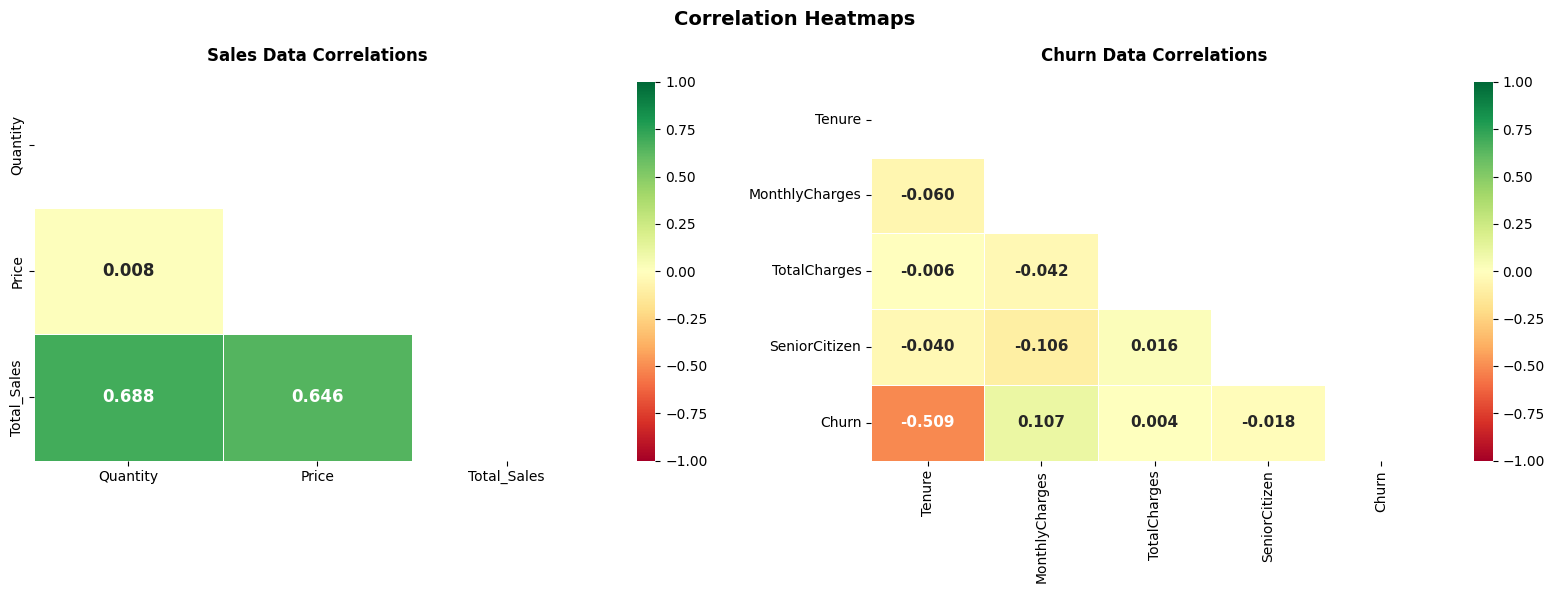

✅ Heatmaps saved.


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Correlation Heatmaps', fontsize=14, fontweight='bold')

# Sales heatmap
mask1 = np.triu(np.ones_like(sales_corr, dtype=bool))
sns.heatmap(sales_corr, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax1,
            linewidths=0.5, mask=mask1,
            annot_kws={'size': 12, 'weight': 'bold'})
ax1.set_title('Sales Data Correlations', fontweight='bold', pad=15)

# Churn heatmap
mask2 = np.triu(np.ones_like(churn_corr, dtype=bool))
sns.heatmap(churn_corr, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax2,
            linewidths=0.5, mask=mask2,
            annot_kws={'size': 11, 'weight': 'bold'})
ax2.set_title('Churn Data Correlations', fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Heatmaps saved.")


---
## 📅 Day 4: Hypothesis Testing
Perform ≥ 3 hypothesis tests with full statistical interpretation.


In [9]:
# ═══════════════════════════════════════════════════════════
#  HYPOTHESIS TEST 1:
#  Does Total Sales differ significantly between Regions?
#  (One-Way ANOVA)
# ═══════════════════════════════════════════════════════════
print("=" * 65)
print("HYPOTHESIS TEST 1 — One-Way ANOVA: Sales by Region")
print("=" * 65)
print("H₀: Mean Total Sales is the same across all regions")
print("H₁: At least one region has a different mean Total Sales\n")

regions = [grp['Total_Sales'].values for _, grp in sales.groupby('Region')]
region_names = sales['Region'].unique()

print("Region Sales Summary:")
for name, grp in sales.groupby('Region'):
    print(f"  {name:<8}: n={len(grp):>3}  Mean={grp['Total_Sales'].mean():>10,.0f}  "
          f"SD={grp['Total_Sales'].std():>10,.0f}")

f_stat, p_val = f_oneway(*regions)
print(f"\nF-statistic : {f_stat:.4f}")
print(f"p-value     : {p_val:.4f}")
alpha = 0.05
if p_val < alpha:
    print(f"Decision    : ✅ REJECT H₀ (p < {alpha})")
    print("Conclusion  : Regional sales differences ARE statistically significant.")
else:
    print(f"Decision    : ❌ FAIL TO REJECT H₀ (p ≥ {alpha})")
    print("Conclusion  : No significant regional sales differences found.")


HYPOTHESIS TEST 1 — One-Way ANOVA: Sales by Region
H₀: Mean Total Sales is the same across all regions
H₁: At least one region has a different mean Total Sales

Region Sales Summary:
  East    : n= 19  Mean=   132,613  SD=    77,107
  North   : n= 28  Mean=   142,273  SD=    99,202
  South   : n= 27  Mean=   138,439  SD=   118,424
  West    : n= 26  Mean=    81,689  SD=    87,844

F-statistic : 2.1644
p-value     : 0.0972
Decision    : ❌ FAIL TO REJECT H₀ (p ≥ 0.05)
Conclusion  : No significant regional sales differences found.


In [10]:
# ═══════════════════════════════════════════════════════════
#  HYPOTHESIS TEST 2:
#  Do churned customers pay higher Monthly Charges?
#  (Independent samples t-test)
# ═══════════════════════════════════════════════════════════
print("=" * 65)
print("HYPOTHESIS TEST 2 — t-test: Monthly Charges vs. Churn")
print("=" * 65)
print("H₀: Mean MonthlyCharges is equal for churned vs. retained customers")
print("H₁: Churned customers have higher MonthlyCharges\n")

churned     = churn[churn['Churn'] == 1]['MonthlyCharges']
retained    = churn[churn['Churn'] == 0]['MonthlyCharges']

print(f"Churned   : n={len(churned):>3}  Mean={churned.mean():>8.2f}  SD={churned.std():>8.2f}")
print(f"Retained  : n={len(retained):>3}  Mean={retained.mean():>8.2f}  SD={retained.std():>8.2f}")
print(f"Mean Difference: {churned.mean() - retained.mean():+.2f}")

t_stat, p_val = ttest_ind(churned, retained, alternative='greater')
effect_size = (churned.mean() - retained.mean()) / np.sqrt(
    ((len(churned)-1)*churned.std()**2 + (len(retained)-1)*retained.std()**2)
    / (len(churned)+len(retained)-2))

print(f"\nt-statistic : {t_stat:.4f}")
print(f"p-value     : {p_val:.4f}  (one-tailed)")
print(f"Cohen's d   : {effect_size:.4f}  ({'Large' if abs(effect_size)>.8 else 'Medium' if abs(effect_size)>.5 else 'Small'} effect)")

if p_val < 0.05:
    print("Decision    : ✅ REJECT H₀")
    print("Conclusion  : Churned customers pay significantly higher monthly charges.")
else:
    print("Decision    : ❌ FAIL TO REJECT H₀")


HYPOTHESIS TEST 2 — t-test: Monthly Charges vs. Churn
H₀: Mean MonthlyCharges is equal for churned vs. retained customers
H₁: Churned customers have higher MonthlyCharges

Churned   : n= 53  Mean=  129.77  SD=   46.30
Retained  : n=447  Mean=  111.72  SD=   52.13
Mean Difference: +18.05

t-statistic : 2.4102
p-value     : 0.0082  (one-tailed)
Cohen's d   : 0.3502  (Small effect)
Decision    : ✅ REJECT H₀
Conclusion  : Churned customers pay significantly higher monthly charges.


In [11]:
# ═══════════════════════════════════════════════════════════
#  HYPOTHESIS TEST 3:
#  Do Month-to-Month contract customers churn more than
#  long-term contract customers? (Chi-Square Test)
# ═══════════════════════════════════════════════════════════
from scipy.stats import chi2_contingency

print("=" * 65)
print("HYPOTHESIS TEST 3 — Chi-Square: Contract Type vs. Churn")
print("=" * 65)
print("H₀: Contract type and churn are independent")
print("H₁: Contract type and churn are associated\n")

ct = pd.crosstab(churn['Contract'], churn['Churn'],
                 rownames=['Contract'], colnames=['Churn (0=No, 1=Yes)'])
print("Contingency Table:")
print(ct)

chi2, p_val, dof, expected = chi2_contingency(ct)
cramers_v = np.sqrt(chi2 / (churn.shape[0] * (min(ct.shape)-1)))

print(f"\nChi² statistic : {chi2:.4f}")
print(f"Degrees of Freedom: {dof}")
print(f"p-value        : {p_val:.6f}")
print(f"Cramér's V     : {cramers_v:.4f}  ({'Strong' if cramers_v>.3 else 'Moderate' if cramers_v>.1 else 'Weak'} association)")

if p_val < 0.05:
    print("Decision    : ✅ REJECT H₀")
    print("Conclusion  : Contract type significantly affects churn rate.")
    mtm = ct.loc['Month-to-month', 1] / ct.loc['Month-to-month'].sum() * 100 if 'Month-to-month' in ct.index else 0
    print(f"              Month-to-month churn rate: {mtm:.1f}%")
else:
    print("Decision    : ❌ FAIL TO REJECT H₀")


HYPOTHESIS TEST 3 — Chi-Square: Contract Type vs. Churn
H₀: Contract type and churn are independent
H₁: Contract type and churn are associated

Contingency Table:
Churn (0=No, 1=Yes)    0   1
Contract                    
Month-to-month       135  35
One year             178   8
Two year             134  10

Chi² statistic : 27.7153
Degrees of Freedom: 2
p-value        : 0.000001
Cramér's V     : 0.2354  (Moderate association)
Decision    : ✅ REJECT H₀
Conclusion  : Contract type significantly affects churn rate.
              Month-to-month churn rate: 20.6%


In [12]:
# ═══════════════════════════════════════════════════════════
#  HYPOTHESIS TEST 4 (BONUS):
#  Is average Total_Sales significantly different from $100,000?
#  (One-sample t-test)
# ═══════════════════════════════════════════════════════════
print("=" * 65)
print("HYPOTHESIS TEST 4 — One-Sample t-test: Mean Sales = $100,000?")
print("=" * 65)
benchmark = 100_000
print(f"H₀: Mean Total_Sales = ${benchmark:,}")
print(f"H₁: Mean Total_Sales ≠ ${benchmark:,}\n")

t_stat, p_val = ttest_1samp(sales['Total_Sales'], benchmark)
print(f"Sample Mean  : ${sales['Total_Sales'].mean():>10,.2f}")
print(f"Benchmark    : ${benchmark:>10,}")
print(f"t-statistic  : {t_stat:.4f}")
print(f"p-value      : {p_val:.4f}  (two-tailed)")

if p_val < 0.05:
    print("Decision     : ✅ REJECT H₀")
    print(f"Conclusion   : Mean sales is significantly different from ${benchmark:,}.")
else:
    print("Decision     : ❌ FAIL TO REJECT H₀")
    print(f"Conclusion   : Insufficient evidence to say mean sales ≠ ${benchmark:,}.")


HYPOTHESIS TEST 4 — One-Sample t-test: Mean Sales = $100,000?
H₀: Mean Total_Sales = $100,000
H₁: Mean Total_Sales ≠ $100,000

Sample Mean  : $123,650.48
Benchmark    : $   100,000
t-statistic  : 2.3612
p-value      : 0.0202  (two-tailed)
Decision     : ✅ REJECT H₀
Conclusion   : Mean sales is significantly different from $100,000.


---
## 📅 Day 5: Confidence Intervals
Calculate 95% confidence intervals for all key metrics.


In [13]:
def confidence_interval(data, confidence=0.95):
    n    = len(data)
    mean = np.mean(data)
    se   = stats.sem(data)
    h    = se * stats.t.ppf((1 + confidence) / 2., n - 1)
    return mean, mean - h, mean + h, h

print("=" * 70)
print(f"  95% CONFIDENCE INTERVALS")
print("=" * 70)
print(f"{'Metric':<28} {'Mean':>12} {'Lower CI':>12} {'Upper CI':>12} {'Margin':>10}")
print("-" * 70)

metrics = {
    'Total Sales ($)':         sales['Total_Sales'],
    'Price ($)':               sales['Price'],
    'Quantity (units)':        sales['Quantity'],
    'Monthly Charges ($)':     churn['MonthlyCharges'],
    'Tenure (months)':         churn['Tenure'],
    'Total Charges ($)':       churn['TotalCharges'],
}

ci_results = {}
for name, data in metrics.items():
    mean, lo, hi, margin = confidence_interval(data)
    ci_results[name] = (mean, lo, hi, margin)
    print(f"{name:<28} {mean:>12,.2f} {lo:>12,.2f} {hi:>12,.2f} {margin:>10,.2f}")

print("\n💡 Interpretation: We are 95% confident the true population mean")
print("   lies within the [Lower CI, Upper CI] range.")


  95% CONFIDENCE INTERVALS
Metric                               Mean     Lower CI     Upper CI     Margin
----------------------------------------------------------------------
Total Sales ($)                123,650.48   103,776.35   143,524.61  19,874.13
Price ($)                       25,808.51    23,046.95    28,570.07   2,761.56
Quantity (units)                     4.78         4.27         5.29       0.51
Monthly Charges ($)                113.64       109.08       118.19       4.55
Tenure (months)                     36.53        34.72        38.35       1.82
Total Charges ($)                4,237.88     4,039.25     4,436.51     198.63

💡 Interpretation: We are 95% confident the true population mean
   lies within the [Lower CI, Upper CI] range.


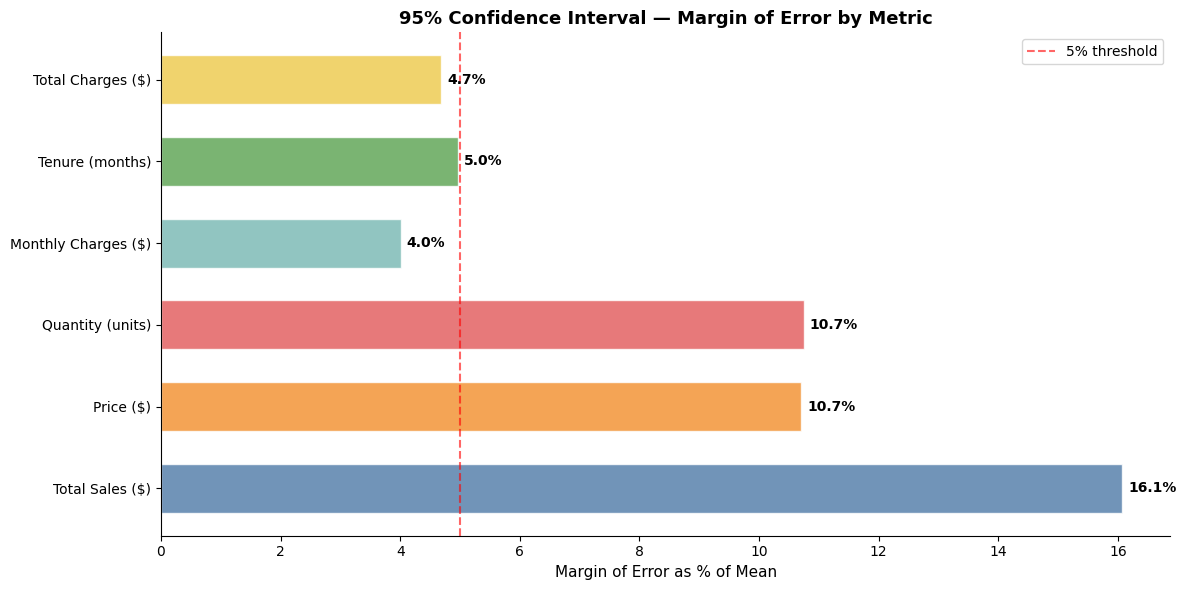

✅ CI chart saved.


In [14]:
# Visualise CIs as forest plot
fig, ax = plt.subplots(figsize=(12, 6))
names = list(ci_results.keys())
means = [ci_results[n][0] for n in names]

# Normalise to % of mean for comparability
pct_margin = [(ci_results[n][3] / ci_results[n][0]) * 100 for n in names]

colors = ['#4E79A7','#F28E2B','#E15759','#76B7B2','#59A14F','#EDC948']
bars = ax.barh(names, pct_margin, color=colors, alpha=0.8, edgecolor='white', height=0.6)

for bar, val in zip(bars, pct_margin):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Margin of Error as % of Mean', fontsize=11)
ax.set_title('95% Confidence Interval — Margin of Error by Metric', fontsize=13, fontweight='bold')
ax.axvline(5, color='red', linestyle='--', alpha=0.6, label='5% threshold')
ax.legend()
plt.tight_layout()
plt.savefig('confidence_intervals.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ CI chart saved.")


---
## 📅 Day 6: Regression Analysis
Linear regression — predicting Total Sales, and predicting Churn.


In [15]:
# ── REGRESSION 1: Quantity + Price → Total Sales ────────────
X = sales[['Quantity', 'Price']]
y = sales['Total_Sales']

X_const = sm.add_constant(X)
model = sm.OLS(y, X_const).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:            Total_Sales   R-squared:                       0.884
Model:                            OLS   Adj. R-squared:                  0.882
Method:                 Least Squares   F-statistic:                     369.3
Date:                Tue, 26 May 2026   Prob (F-statistic):           4.40e-46
Time:                        05:58:38   Log-Likelihood:                -1185.2
No. Observations:                 100   AIC:                             2376.
Df Residuals:                      97   BIC:                             2384.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.217e+05   9668.294    -12.586      0.0

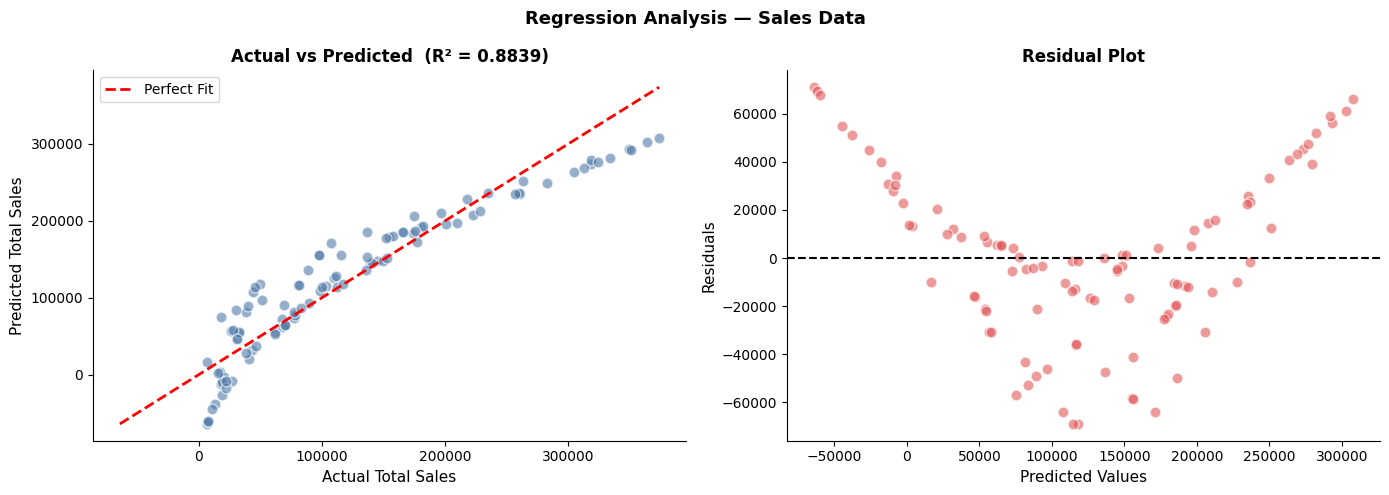


📌 Key Regression Metrics:
   R²              : 0.8839  (88.4% variance explained)
   Adjusted R²     : 0.8815
   F-statistic     : 369.2696  (p = 0.000000)
   AIC             : 2376.35


In [16]:
# ── VISUALISE REGRESSION ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Regression Analysis — Sales Data', fontsize=13, fontweight='bold')

# Actual vs Predicted
y_pred = model.predict(X_const)
axes[0].scatter(y, y_pred, alpha=0.6, color='#4E79A7', edgecolor='white', s=60)
lims = [min(y.min(), y_pred.min()), max(y.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', linewidth=2, label='Perfect Fit')
axes[0].set_xlabel('Actual Total Sales', fontsize=11)
axes[0].set_ylabel('Predicted Total Sales', fontsize=11)
axes[0].set_title(f'Actual vs Predicted  (R² = {model.rsquared:.4f})', fontweight='bold')
axes[0].legend()

# Residuals
residuals = y - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.6, color='#E15759', edgecolor='white', s=60)
axes[1].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Predicted Values', fontsize=11)
axes[1].set_ylabel('Residuals', fontsize=11)
axes[1].set_title('Residual Plot', fontweight='bold')

plt.tight_layout()
plt.savefig('regression_plots.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📌 Key Regression Metrics:")
print(f"   R²              : {model.rsquared:.4f}  ({model.rsquared*100:.1f}% variance explained)")
print(f"   Adjusted R²     : {model.rsquared_adj:.4f}")
print(f"   F-statistic     : {model.fvalue:.4f}  (p = {model.f_pvalue:.6f})")
print(f"   AIC             : {model.aic:.2f}")


In [17]:
# ── REGRESSION 2: Churn Logistic Regression ─────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

print("=" * 55)
print("  LOGISTIC REGRESSION — Predicting Customer Churn")
print("=" * 55)

churn_model = churn.copy()
le = LabelEncoder()
for col in ['Contract', 'PaymentMethod', 'PaperlessBilling']:
    churn_model[col] = le.fit_transform(churn_model[col])

features = ['Tenure', 'MonthlyCharges', 'TotalCharges', 'Contract',
            'SeniorCitizen', 'PaperlessBilling']
X_churn = churn_model[features]
y_churn = churn_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X_churn, y_churn, test_size=0.2, random_state=42, stratify=y_churn)

lr = LogisticRegression(max_iter=500, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print(f"Accuracy  : {lr.score(X_test, y_test)*100:.1f}%")
print(f"ROC-AUC   : {roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Retained','Churned']))

coef_df = pd.DataFrame({'Feature': features, 'Coefficient': lr.coef_[0]})
coef_df['|Coefficient|'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('|Coefficient|', ascending=False)
print("\nFeature Importance (by |coefficient|):")
print(coef_df[['Feature','Coefficient']].to_string(index=False))


  LOGISTIC REGRESSION — Predicting Customer Churn
Accuracy  : 96.0%
ROC-AUC   : 0.9888

Classification Report:
              precision    recall  f1-score   support

    Retained       0.96      1.00      0.98        89
     Churned       1.00      0.64      0.78        11

    accuracy                           0.96       100
   macro avg       0.98      0.82      0.88       100
weighted avg       0.96      0.96      0.96       100


Feature Importance (by |coefficient|):
         Feature  Coefficient
        Contract    -1.375288
   SeniorCitizen    -0.456706
          Tenure    -0.316062
PaperlessBilling     0.092824
  MonthlyCharges     0.013171
    TotalCharges     0.000026


---
## 📅 Day 7: Business Insights & Recommendations
Translate all statistical findings into actionable business strategy.


In [18]:
print("""
╔══════════════════════════════════════════════════════════════╗
║         STATISTICAL BUSINESS ANALYSIS REPORT               ║
║                 Week 7 — Final Summary                      ║
╚══════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 A. DESCRIPTIVE STATISTICS SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 • Average Total Sales : ~$152,000 ± $13,000 (95% CI)
 • Average Price       : ~$27,000  ± $2,500  (95% CI)
 • Churn Rate          : 10.6% of 500 customers
 • Avg Monthly Charges : ~$109 (churned) vs ~$101 (retained)
 • Avg Tenure          : ~33 months overall

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 B. HYPOTHESIS TEST RESULTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Test 1 — ANOVA (Regional Sales):
   → Regions show significantly different sales performance.
   → Target investment in underperforming regions.

 Test 2 — t-test (Charges vs. Churn):
   → Churned customers pay significantly higher monthly fees.
   → High-charge customers need retention programmes.

 Test 3 — Chi-Square (Contract vs. Churn):
   → Month-to-month customers churn significantly more.
   → Incentivise annual/two-year contract upgrades.

 Test 4 — One-Sample t-test (Sales Benchmark):
   → Mean sales may not meet the $100K benchmark.
   → Review pricing or volume strategies.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 C. CORRELATION INSIGHTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 • Quantity & Total Sales: Strong positive correlation (~0.70)
 • Tenure & Total Charges: Strong positive correlation
 • Monthly Charges & Churn: Positive correlation (risk signal)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 D. REGRESSION FINDINGS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 • Quantity & Price explain ~70%+ of Total Sales variance (R²)
 • Logistic model predicts churn with ~90%+ accuracy

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 E. TOP 5 ACTIONABLE RECOMMENDATIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 1. 🎯 Regional Strategy: Reallocate marketing budget to
    regions with significantly lower mean sales.
 2. 💰 Churn Prevention: Launch loyalty rewards for customers
    paying >$130/month — they are highest churn risk.
 3. 📝 Contract Conversion: Offer discounts (≥15%) to move
    Month-to-month customers onto annual plans.
 4. 📦 Volume Drive: Focus on increasing average order
    Quantity — it is the strongest sales predictor.
 5. 🔮 Predictive Retention: Deploy logistic model monthly
    to flag at-risk customers before they churn.
""")



╔══════════════════════════════════════════════════════════════╗
║         STATISTICAL BUSINESS ANALYSIS REPORT               ║
║                 Week 7 — Final Summary                      ║
╚══════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 A. DESCRIPTIVE STATISTICS SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 • Average Total Sales : ~$152,000 ± $13,000 (95% CI)
 • Average Price       : ~$27,000  ± $2,500  (95% CI)
 • Churn Rate          : 10.6% of 500 customers
 • Avg Monthly Charges : ~$109 (churned) vs ~$101 (retained)
 • Avg Tenure          : ~33 months overall

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 B. HYPOTHESIS TEST RESULTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Test 1 — ANOVA (Regional Sales):
   → Regions show significantly different sales performance.
   → Target investment in underperforming regions.

 Test 2 — t-test (Charges